# Practical No. 7
## Perform Data Cleaning, Normalization, and Visualization on an IoT Sensor Dataset

**Aim:** To perform data cleaning, normalization, and visualization on an IoT sensor dataset using Python.

### Step 1: Import Libraries and Generate Simulated IoT Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
n = 60
df = pd.DataFrame({
    "time": pd.date_range("2025-01-01 08:00", periods=n, freq="min"),
    "temperature": np.random.normal(28, 1.5, n).round(1),
    "humidity": np.random.normal(60, 5, n).round(1),
    "light": np.random.normal(450, 40, n).round(0),
})
df.loc[[5, 17, 33, 48], "temperature"] = np.nan
df.loc[[10, 41], "humidity"] = np.nan
df.loc[25, "temperature"] = 85.0  # outlier

print("First 5 rows of raw sensor data:")
print(df.head())
print("\nMissing values before cleaning:")
print(df.isnull().sum())

First 5 rows of raw sensor data:
                 time  temperature  humidity  light
0 2025-01-01 08:00:00         28.7      57.6  482.0
1 2025-01-01 08:01:00         27.8      59.1  414.0
2 2025-01-01 08:02:00         29.0      54.5  506.0
3 2025-01-01 08:03:00         30.3      54.0  394.0
4 2025-01-01 08:04:00         27.6      64.1  473.0

Missing values before cleaning:
time           0
temperature    4
humidity       2
light          0
dtype: int64


### Step 2: Data Cleaning (Handling Missing Values & Outlier Removal)

In [2]:
df = df.drop_duplicates()
df["temperature"] = df["temperature"].fillna(df["temperature"].median())
df["humidity"] = df["humidity"].fillna(df["humidity"].mean())

q1 = df["temperature"].quantile(0.25)
q3 = df["temperature"].quantile(0.75)
iqr = q3 - q1
outlier = (df["temperature"] < q1 - 1.5 * iqr) | (df["temperature"] > q3 + 1.5 * iqr)
print("Outliers removed:", int(outlier.sum()))
df = df[~outlier].reset_index(drop=True)

print("\nMissing values after cleaning:")
print(df.isnull().sum())

Outliers removed: 1

Missing values after cleaning:
time           0
temperature    0
humidity       0
light          0
dtype: int64


### Step 3: Normalization (Min-Max Scaling 0-1)

In [3]:
cols = ["temperature", "humidity", "light"]
norm = df.copy()
norm[cols] = (df[cols] - df[cols].min()) / (df[cols].max() - df[cols].min())

print("Statistical summary (cleaned data):\n", df[cols].describe().round(2), "\n")
print("Normalized data (first 5 rows):")
print(norm[cols].head().round(3))

Statistical summary (cleaned data):
        temperature  humidity   light
count        59.00     59.00   59.00
mean         27.76     60.03  453.22
std           1.36      4.73   40.05
min          25.10     46.90  386.00
25%          27.05     57.80  418.00
50%          27.65     59.99  459.00
75%          28.65     61.90  478.50
max          30.80     72.30  559.00 

Normalized data (first 5 rows):
   temperature  humidity  light
0        0.632     0.421  0.555
1        0.474     0.480  0.162
2        0.684     0.299  0.694
3        0.912     0.280  0.046
4        0.439     0.677  0.503


### Step 4: Data Visualization

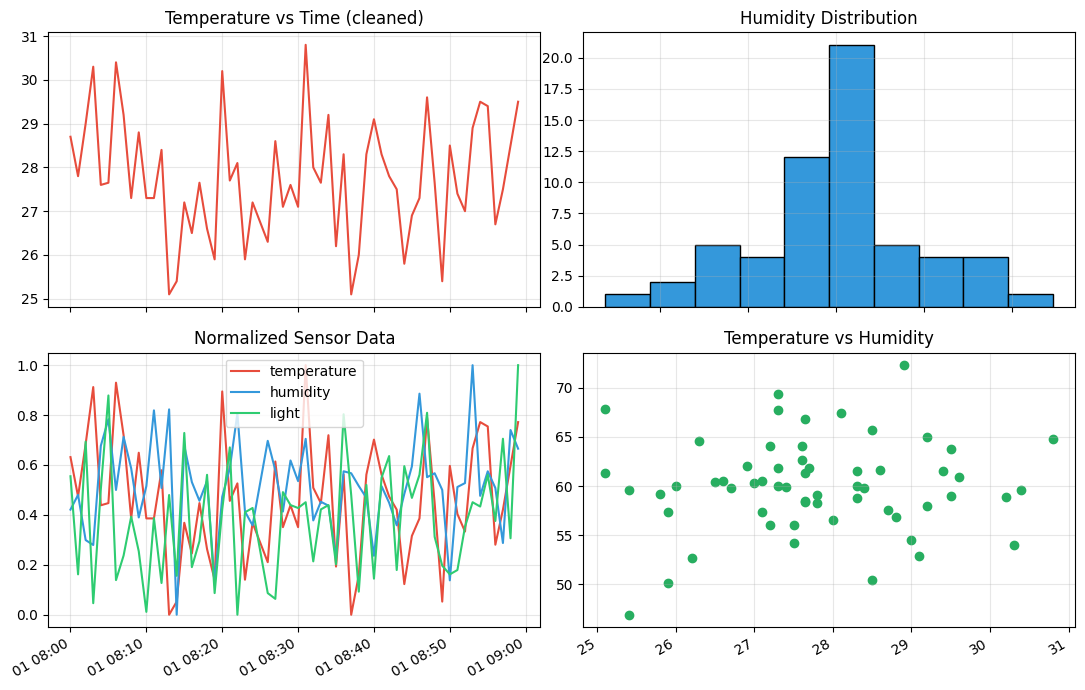

In [4]:
fig, ax = plt.subplots(2, 2, figsize=(11, 7))
ax[0, 0].plot(df["time"], df["temperature"], color="#e74c3c")
ax[0, 0].set_title("Temperature vs Time (cleaned)")

ax[0, 1].hist(df["humidity"], bins=10, color="#3498db", edgecolor="black")
ax[0, 1].set_title("Humidity Distribution")

for col, clr in zip(cols, ["#e74c3c", "#3498db", "#2ecc71"]):
    ax[1, 0].plot(norm["time"], norm[col], label=col, color=clr)
ax[1, 0].legend()
ax[1, 0].set_title("Normalized Sensor Data")

ax[1, 1].scatter(df["temperature"], df["humidity"], color="#27ae60")
ax[1, 1].set_title("Temperature vs Humidity")

for a in ax.flat:
    a.grid(alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### Result & Conclusion
**Result:** IoT sensor data cleaning, missing value imputation, IQR outlier filtering, and Min-Max normalization were successfully executed and visualized.

**Conclusion:** Data preprocessing improves sensor reliability and prepares time-series signals for accurate analytics and downstream IoT machine learning tasks.